In [2]:
import importlib
import pandas as pd
import preprocess_behav2p as preprocess
import analysis_functions as af
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
import os
import pickle
from matplotlib.animation import FuncAnimation
from io_utils import save_pickle, load_pickle
import init_vars as iv
import visualize as viz
import scipy
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter1d

In [ ]:
# # RELOAD 
# importlib.reload(preprocess)
# data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
# sheet_name = 'LC_DREADDs'
# table = pd.read_excel(data_dir, sheet_name=sheet_name)
# comb = {}
# neuropil_factor = 0.3
# tri_perc = 1
# for ani in range(4,8):
#     # Run preprocessing for each animal/session
#     ani, pp = preprocess.main(ani, table,sheet_name, neuropil_factor, tri_perc,basesub=1, roitype='red')
#     comb[ani] = {
#         'n_gratings': pp.n_gratings,
#         'unpred_trials': pp.unpred_trials,
#         'pred_trials': pp.pred_trials,
#         'trial_start_indices': pp.trial_start_indices,
#         'grating_indices': pp.grating_indices,
#         'dff_Zscore': pp.dff_Zscore,
#         'n_planes': pp.n_planes,
#         'n_trial': pp.n_trials,
#         'aligned_data': pp.aligned_data,
#         'reward_indices': pp.reward_indices,
#         'activity': pp.activity,
#         'TC': pp.TC,
#         'position': pp.position,
#         'position_tunnel': pp.position_tunnel,
#         'speed': pp.speed,
#         'trial_type': pp.trial_types,
#         'pupil': pp.pupil,
#         'lick': pp.lick
#     }

# data = {}
# importlib.reload(iv)
# for ani in comb.keys():
#     data[ani] ={}
#     data[ani]['aligned_data'] = comb[ani]['aligned_data']
#     data[ani]['activity'] = comb[ani]['activity']
#     data[ani]['unpred_trials'] = comb[ani]['unpred_trials']
#     data[ani]['pred_trials'] = comb[ani]['pred_trials']
#     data[ani]['dff_Zscore'] = comb[ani]['dff_Zscore']
#     data[ani]['trial_start_indices'] = comb[ani]['trial_start_indices']
#     data[ani]['type'] = table.iloc[ani][3]
#     data[ani]['grating_indices']= comb[ani]['grating_indices']
#     data[ani]['reward_indices']= comb[ani]['reward_indices']
#     data[ani]['n_gratings'] = comb[ani]['n_gratings']
#     data[ani]['n_trial'] = comb[ani]['n_trial']
#     if table.iloc[ani][1] == 1:
#         data[ani]['position_tunnel'] = comb[ani]['position_tunnel']
#         data[ani]['position'] = comb[ani]['position']
#         data[ani]['speed'] = comb[ani]['speed']
#         data[ani]['lick'] = comb[ani]['lick']
#         data[ani]['pupil'] = comb[ani]['pupil']
#     else:
#         data[ani]['position'] = comb[ani]['aligned_data' ]['Averaged_Position']
#         try:
#             data[ani]['pupil'] = comb[ani]['aligned_data']['pupil_diameter']
            # data[ani] = iv.process_pupil(data[ani])
#         except KeyError:
#             data[ani]['pupil'] = None

#         data[ani]['speed'] = comb[ani]['aligned_data']['Speed_Absolute']
#         data[ani] = iv.process_speed(data[ani])

#     save_pickle(data[ani], "all_data", base_path=table.iloc[ani][2])

In [24]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data = {}
neuropil_factor = 0.3
tri_perc = 1
ani_range = range(2,6)
for ani in ani_range:
    data[ani] = load_pickle('all_data',base_path=table.iloc[ani][2])

In [25]:
importlib.reload(af)
importlib.reload(iv)
colors = sns.color_palette("mako", 13)
poststim_frames = slice(23,33) 
prestim_frames = slice(10,15)   # stim at frame 20
max_tr, thres = 5, 0.5
blo1trials, blo2trials, sig_cells = {}, {}, {}

for ani in ani_range:
    unpred_gratings = iv.get_unpred_grats(data[ani])
    blo1, blo2 = iv.init_trial_blocks(unpred_gratings, max_tr=max_tr)
    btri = iv.sparse_pred_trials(data[ani], unpred_gratings, max_tr, method='simple') 
    data[ani]['pred_trials'] = np.setdiff1d(np.arange(data[ani]['activity']['gr_1'].shape[1]),np.concatenate(list(unpred_gratings.values())))
    if len(btri) > 0:
        blo1['gr_2'] = btri
        blo2['gr_2'] = btri
    if "X0" in blo1:
        blo1['gr_1'] = blo1["X0"]
        blo2['gr_1'] = blo2["X0"]
    blo1trials[ani], blo2trials[ani] = blo1, blo2
    mapping = {'gr_1': 'gr_1', 'gr_2': 'gr_2','X0': 'gr_2'}
    sig_cells[ani] = iv.get_sig_cells(data[ani], blo1, blo2, mapping, thres, prestim_frames, poststim_frames,method='thresh')


In [5]:
tst = [0,2,4,6]
ctl = [1,3,5,7]

IndexError: index 25 is out of bounds for axis 0 with size 24

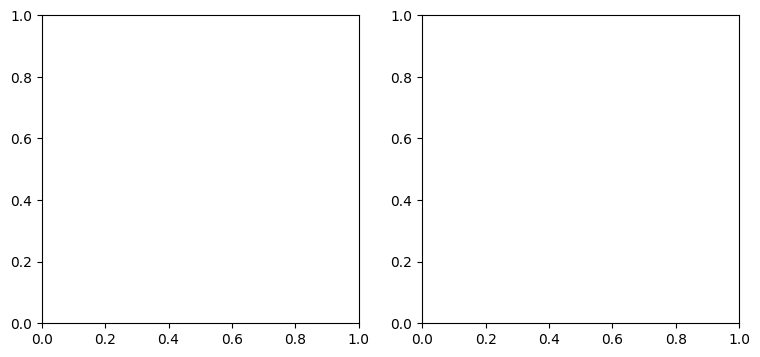

In [13]:
tst = [0,2]
ctl =[1,3]
fig, ax = plt.subplots(1, 2, figsize=(9,4))
axes = ax[0]
grat = 'gr_2'
trials = blo1trials[ani][grat]
sal = []
sal_unpred = []
for _,ani in enumerate(ctl):
    sal.append(np.nanmean(data[ani]['pupil_rel'][grat][trials,:],axis=0))
    sal_unpred.append(np.nanmean(data[ani]['pupil_rel'][grat][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline pred',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal_unpred),color='lightgrey',label='saline, unpred')

cno = []
cno_unpred = []
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel'][grat][trials,:],axis=0))
    cno_unpred.append(np.nanmean(data[ani]['pupil_rel'][grat][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO pred',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO unpred')

axes.set_ylabel('relative pupil size')
axes.set_yticks([])
axes.set_xticks([11.5, 19, 37])
axes.set_xticklabels(['-1', '0', '2.4'])
axes.axvline(19, linestyle='--', color='k')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_title('grating 2')
axes = ax[1]
grat = 'gr_2'
trials = blo1trials[ani][grat]
sal = []
sal_unpred = []
for _,ani in enumerate(ctl):
    sal.append(np.nanmean(data[ani]['pupil_rel']['rew'][trials,:],axis=0))
    sal_unpred.append(np.nanmean(data[ani]['pupil_rel']['rew'][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(sal),color='grey',label='saline',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(sal_unpred),color='lightgrey',label='saline, unpred')

cno = []
cno_unpred = []
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel']['rew'][trials,:],axis=0))
    cno_unpred.append(np.nanmean(data[ani]['pupil_rel']['rew'][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(cno),color='mediumvioletred',label='CNO',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO')

axes.axvline(20, linestyle='--', color='k')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_yticks([])
axes.set_xticks([11.5, 19, 27.5])
axes.set_xticklabels(['-1', '0', '1'])
axes.set_title('reward')
axes.legend('')

Text(0.5, 1.0, 'reward')

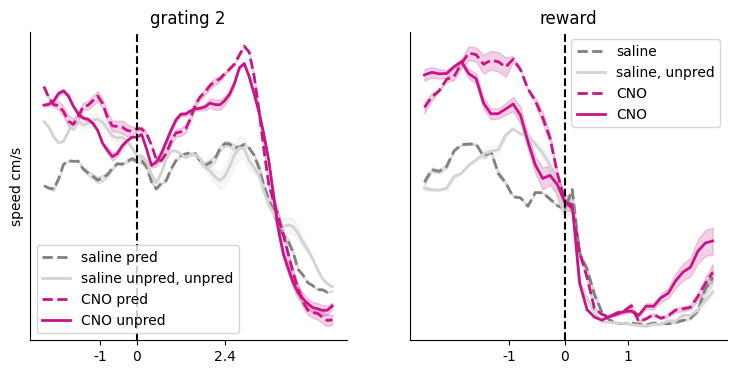

In [ ]:
tst = [0,2]
ctl =[1,3]
fig, ax = plt.subplots(1, 2, figsize=(9,4))
axes = ax[0]
grat = 'gr_2'
trials = blo1trials[ani][grat]
sal = []
sal_unpred = []
for _,ani in enumerate(ctl):
    sal.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,:],axis=0))
    sal_unpred.append(np.nanmean(data[ani]['speed_cm_s'][grat][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline pred',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal_unpred),color='lightgrey',label='saline unpred, unpred')

cno = []
cno_unpred = []
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,:],axis=0))
    cno_unpred.append(np.nanmean(data[ani]['speed_cm_s'][grat][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO pred',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO unpred')

axes.set_ylabel('speed cm/s')
axes.set_yticks([])
axes.set_xticks([11.5, 19, 37])
axes.set_xticklabels(['-1', '0', '2.4'])
axes.axvline(19, linestyle='--', color='k')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_title('grating 2')
axes = ax[1]
grat = 'gr_2'
trials = blo1trials[ani][grat]
sal = []
sal_unpred = []
for _,ani in enumerate(ctl):
    sal.append(np.nanmean(data[ani]['speed_cm_s']['rew'][trials,:],axis=0))
    sal_unpred.append(np.nanmean(data[ani]['speed_cm_s']['rew'][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(sal),color='grey',label='saline',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(sal_unpred),color='lightgrey',label='saline, unpred')

cno = []
cno_unpred = []
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['speed_cm_s']['rew'][trials,:],axis=0))
    cno_unpred.append(np.nanmean(data[ani]['speed_cm_s']['rew'][data[ani]['unpred_trials'][grat][:8],:],axis=0))

viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(cno),color='mediumvioletred',label='CNO',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO')

axes.axvline(19, linestyle='--', color='k')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_yticks([])
axes.set_xticks([11.5, 19, 27.5])
axes.set_xticklabels(['-1', '0', '1'])
axes.set_title('reward')

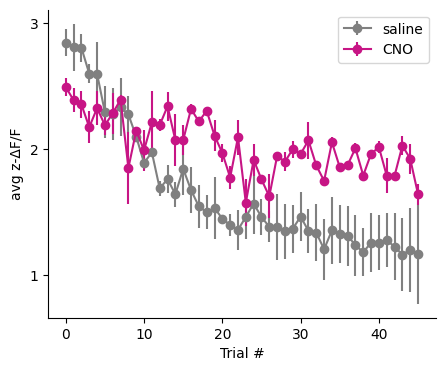

In [8]:
tst = [0,2]
ctl =[1,3]
fig, axes = plt.subplots(1, 1, figsize=(5,4))
min_trials = min([len(data[ani]['unpred_trials']['gr_2']) for ani in ani_range])
x_vals = list(range(min_trials))
axes.set_ylabel('avg z-ΔF/F')
grat= 'gr_2'
poststim_frames = slice(23,33)
sal = []
for _,ani in enumerate(ctl):
    sal.append(np.mean(np.max(data[ani]['activity'][grat][sig_cells[ani]['X0']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
# (cell,trial,frames), average the maximum response in the poststim frames in all cells

axes.errorbar(x_vals, np.mean(sal, axis=0),np.std(sal, axis=0) / np.sqrt(len(sal)),fmt='o-', color='grey', label='saline')
# x_vals, y_vals, error_bars, SEM = std/sqrt

cno = []
for _,ani in enumerate(tst):
    cno.append(np.mean(np.max(data[ani]['activity'][grat][sig_cells[ani]['X0']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))

axes.errorbar(x_vals, np.mean(cno, axis=0),np.std(cno, axis=0) / np.sqrt(len(cno)),fmt='o-', color='mediumvioletred', label='CNO')


axes.set_yticks([1,2,3])
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_xlabel('Trial #')
axes.legend()

Text(45.722222222222214, 0.5, '# neurons')

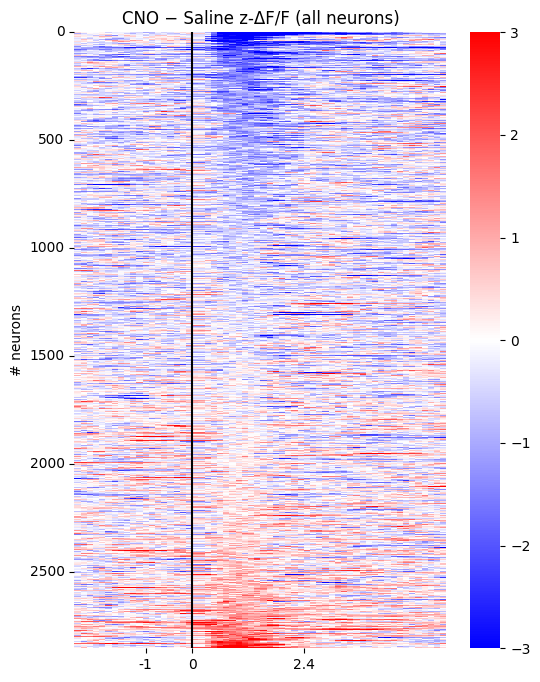

In [9]:
grat = 'gr_2'
min_trials = 5
sort_frames = slice(23, 30)
vmin, vmax = -3, 3
all_neurons = []

for ani in range(0, len(data), 2): 
    activity_cno = data[ani]['activity'][grat]
    activity_saline = data[ani + 1]['activity'][grat]

    trials_cno = data[ani]['unpred_trials'][grat][:min_trials]
    trials_saline = data[ani + 1]['unpred_trials'][grat][:min_trials]

    plot_data = np.mean(activity_cno[:, trials_cno, :], axis=1) - np.mean(activity_saline[:, trials_saline, :], axis=1) # response difference in cno and saline trials
    all_neurons.append(plot_data)
    
all_neurons = np.vstack(all_neurons)
sort_idx = np.argsort(np.mean(all_neurons[:, sort_frames], axis=1))  # sort by mean poststim response
all_neurons_sorted = all_neurons[sort_idx]

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
sns.heatmap(all_neurons_sorted, ax=ax, cmap='bwr', cbar=True,vmin=vmin,vmax=vmax)

ax.set_xticks([11.5, 19, 37])
ax.set_xticklabels(['-1', '0', '2.4'])
ax.axvline(19, linestyle='-', color='k')
ax.set_title(f'CNO − Saline z-ΔF/F (all neurons)')

y_ticks = np.arange(0, all_neurons_sorted.shape[0], 500)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks)
ax.set_ylabel('# neurons')


Text(0.5, 1.0, 'grating 2')

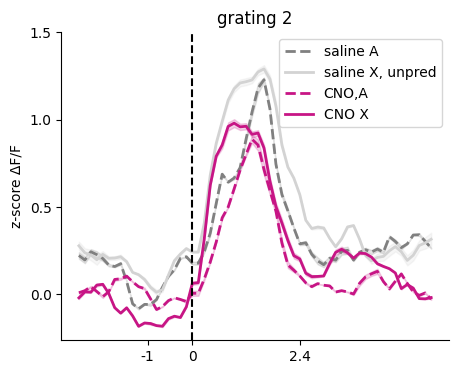

In [ ]:
tst = [0,2]
ctl =[1,3]
fig, axes = plt.subplots(1, 1, figsize=(5,4))

sal = []
sal_unpred = []
for _,ani in enumerate(ctl):
    trials = data[ani]['unpred_trials']['gr_2'][:4]
    sal.append(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,trials,:].mean(axis=(1,0)) )
    sal_unpred.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,trials,:].mean(axis=(1,0)) )

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline A',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal_unpred),color='lightgrey',label='saline X, unpred')

cno = []
cno_unpred = []
for _,ani in enumerate(tst):
    trials = data[ani]['unpred_trials']['gr_2'][:6]
    cno.append(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,trials,:].mean(axis=(1,0)) )
    cno_unpred.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,trials,:].mean(axis=(1,0)) )

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO,A',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO X')

axes.set_ylabel('z-score ΔF/F')
axes.set_yticks([0,0.5,1,1.5])
axes.set_xticks([11.5, 19, 37])
axes.set_xticklabels(['-1', '0', '2.4'])
axes.axvline(19, linestyle='--', color='k')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_title('grating 2')


Text(0, 0.5, 'peak z-ΔF/F')

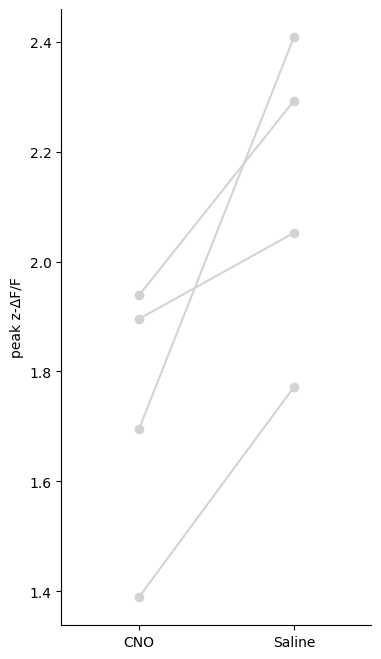

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(4, 8))

min_trials = 4
grat = 'gr_2'

x = [1, 2]  # Saline, CNO

for ani in range(0, len(data), 2):
    mouse1 = []
    for sess in [ani, ani + 1]:
        val = np.mean(
            np.max(data[sess]['activity'][grat][sig_cells[sess]['all']][:, data[sess]['unpred_trials'][grat][:min_trials], poststim_frames],axis=2),axis=(0, 1))
        mouse1.append(val)

    ax.plot(x,mouse1,'o-',color='lightgrey')

ax.set_xlim([0.5, 2.5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([1, 2])
ax.set_xticklabels(['CNO', 'Saline'])
ax.set_ylabel('peak z-ΔF/F')


Text(0, 0.5, 'CNO')

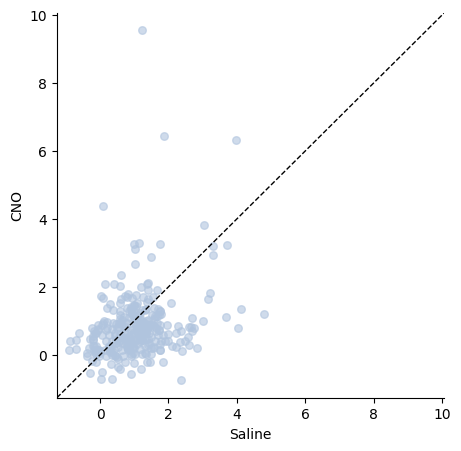

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
mark_size = 30
min_trials = 6
grat = 'gr_2'

for ani in range(0, len(data), 2):
    sess_cno = ani
    sess_saline = ani + 1
    rois = np.intersect1d(sig_cells[sess_cno]['X0'],sig_cells[sess_saline]['X0']) # rois that occurs in CNO and saline sessions on two neighboring days
    for roi in rois:
        cno_val = np.mean(np.mean(data[sess_cno]['activity'][grat][roi][data[sess_cno]['unpred_trials'][grat][:min_trials], poststim_frames],axis=1))
        saline_val = np.mean(np.mean(data[sess_saline]['activity'][grat][roi][data[sess_saline]['unpred_trials'][grat][:min_trials], poststim_frames],axis=1))
 
        ax.scatter(saline_val,cno_val,color='lightsteelblue',alpha=0.6,s=mark_size)

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]

ax.plot(lims, lims, 'k--', lw=1) # set the x and y coordinate limits

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Saline')
ax.set_ylabel('CNO')


first with in saline sessions pupil response correlated with unexpected -expected, then in CNO trials.

(-8.0, 8.0)

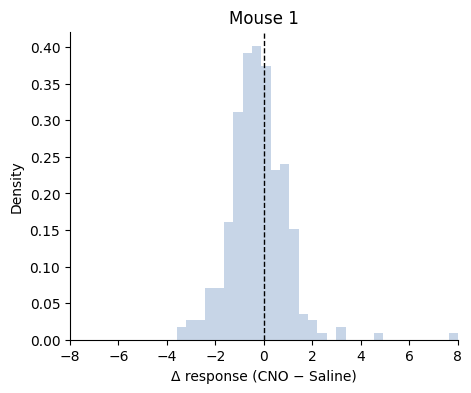

In [13]:
fig, axes = plt.subplots(1,1,figsize=(5, 4))
min_trials = 4
grat = 'gr_2'

all_delta = []
for ani in range(0, len(data), 2):
    sess_cno = ani
    sess_saline = ani + 1
    rois = np.intersect1d(sig_cells[sess_cno]['X0'],sig_cells[sess_saline]['X0'])
    for roi in rois:
        cno_val = np.mean(np.mean(data[sess_cno]['activity'][grat][roi][data[sess_cno]['unpred_trials'][grat][:min_trials], poststim_frames],axis=1))
        saline_val = np.mean(np.mean(data[sess_saline]['activity'][grat][roi][data[sess_saline]['unpred_trials'][grat][:min_trials], poststim_frames],axis=1))
        all_delta.append(cno_val - saline_val)

axes.hist(np.array(all_delta),bins=30,color='lightsteelblue',alpha=0.7,density=True)
axes.axvline(0, color='k', ls='--', lw=1)
axes.set_xlabel('Δ response (CNO − Saline)')
axes.set_ylabel('Density')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_title('Mouse 1')
axes.set_xlim([-8,8])


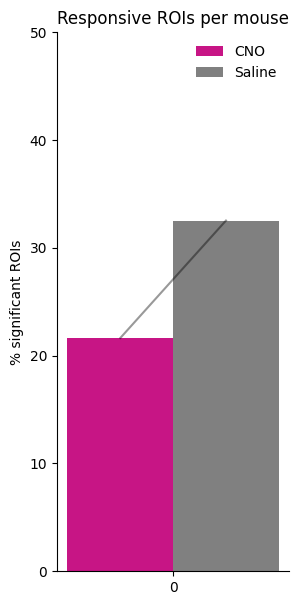

In [14]:
mouse_ids = { 0: [0,2]}
pct_cno = []
pct_saline = []
for mouse, cno_sessions in mouse_ids.items():
    cno_sig = []
    saline_sig = []

    for s in cno_sessions:
        cno_sig.append(len(sig_cells[s]['X0'])/data[s]['activity']['gr_1'].shape[0])       # CNO
        saline_sig.append(len(sig_cells[s+1]['X0'])/data[s+1]['activity']['gr_1'].shape[0])  # paired saline

    pct_cno.append(100 * np.mean(cno_sig))
    pct_saline.append(100 * np.mean(saline_sig))


x = np.arange(1) 
width = 0.25
fig, ax = plt.subplots(figsize=(3, 7))

ax.bar(x - width/2,pct_cno,width,color='mediumvioletred',label='CNO')
ax.bar(x + width/2,pct_saline,width,color='grey',label='Saline')
ax.plot( [x[0] - width/2, x[0] + width/2], [pct_cno[0], pct_saline[0]],color='k',alpha=0.4)
ax.set_xticks(x)
ax.set_ylabel('% significant ROIs')
ax.set_ylim(0, 50)
ax.legend(frameon=False)
ax.set_title('Responsive ROIs per mouse')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

track single cells’ responses over sessions (used roicat!) --- let's see if 3 sessions work --- good, so D&E(CNO)&F 

correlate pupil and running speed with neural activity for A and X responses in both CNO and saline sessions

maybe also: how does cno affect selectivity of responses ?

another analysis could be doing is comparing passive lick speed and pupil d1-5 and then do the same with active context guys (can also run roicat on the active guys just day 1,5,C for example: 445_LR, 445_R, 444_L, 442_L, 442_L) --- some all_data files are missing

correlate pupil size with CNO/ saline unexpected trials (block1)
correlate pupil size with CNO/ saline predicted trials (block2)

On the Y axis: difference in avg activity in high pupil size trials and low pupil size trials
On the X axis: difference in activity in saline unpred trials and CNO unpred trials

In [1]:
# Dreadds 1

fig, ax = plt.subplots(1,1, figsize=(5,4))
cno = []
cno_late = []
tst = []
for _,ani in enumerate(ani_range):
    # pupil = data[ani]['aligned_data']['pupil_long_axis'].values
    # low, high = np.nanpercentile(pupil, 0.5), np.nanpercentile(pupil, 99.5)
    # pupil[(pupil < low) | (pupil > high)] = np.nan
    # pupil = gaussian_filter1d(pupil, sigma=1)
    # cno.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_1'][:60]],axis=0))
    # cno_late.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_1'][60:120]],axis=0))
    pupil = data[ani]['pupil_rel']
    cno.append(np.nanmean(pupil['gr_1'][:60],axis=0))
    cno_late.append(np.nanmean(pupil['gr_1'][100:160],axis=0))
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='cno',style='dash')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='cno late')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 27.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('CNO')

NameError: name 'plt' is not defined

ValueError: need at least one array to concatenate

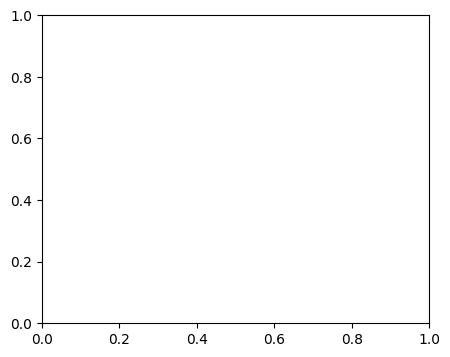

In [14]:
# Dreadds 1

fig, ax = plt.subplots(1,1, figsize=(5,4))
cno = []
cno_late = []
tst = []
for _,ani in enumerate(tst):
    pupil = data[ani]['aligned_data']['pupil_long_axis'].values
    low, high = np.nanpercentile(pupil, 0.5), np.nanpercentile(pupil, 99.5)
    pupil[(pupil < low) | (pupil > high)] = np.nan
    pupil = gaussian_filter1d(pupil, sigma=1)
    cno.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_1'][:60]],axis=0))
    cno_late.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_1'][100:60]],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='grey',label='cno',style='dash')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno_late),color='lightgrey',label='cno late')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 27.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('CNO')

Text(0.5, 1.0, 'grat1')

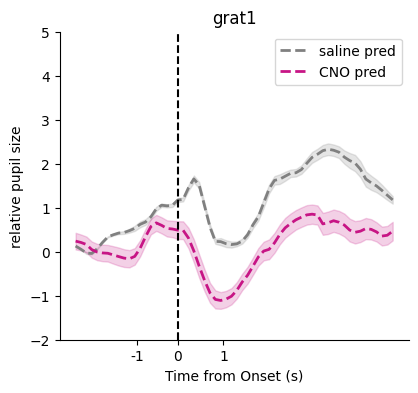

In [18]:
# Dreadds 1 grat 1 CNO & saline  First 10 trials

fig, ax = plt.subplots(figsize=(4.5,4))
sal = []
cno = []
ctl = [1,3]
tst = [0,2]
sal_unpred = []
for _,ani in enumerate(ctl):
    sal.append(np.nanmean(data[ani]['pupil_rel']['gr_1'][data[ani]['pred_trials'][:15],:],axis=0))
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel']['gr_1'][data[ani]['pred_trials'][:15],:],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline pred',style='dash')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO pred',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-2,5])
# ax.set_yticks([])
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 27.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('grat1')


Text(0.5, 1.0, 'grat1')

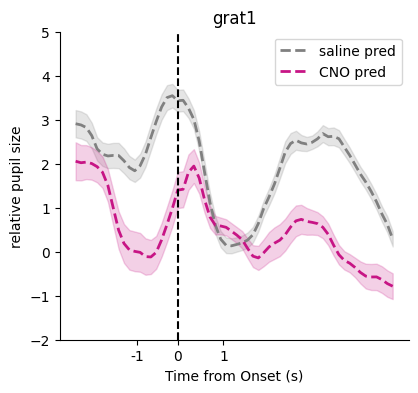

In [19]:
# Dreadds 1 grat 1 CNO & saline   First 10 trials

ctl = [5,7]
tst = [4,6]

fig, ax = plt.subplots(figsize=(4.5,4))
sal = []
cno = []
sal_unpred = []
for _,ani in enumerate(ctl):
    sal.append(np.nanmean(data[ani]['pupil_rel']['gr_1'][data[ani]['pred_trials'][:15],:],axis=0))
for _,ani in enumerate(tst):
    cno.append(np.nanmean(data[ani]['pupil_rel']['gr_1'][data[ani]['pred_trials'][:15],:],axis=0))

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline pred',style='dash')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO pred',style='dash')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-2,5])
# ax.set_yticks([])
ax.set_ylabel('relative pupil size')
ax.set_xticks([11.5, 19, 27.5])
ax.set_xticklabels(['-1', '0', '1'])
ax.set_xlabel('Time from Onset (s)')
ax.set_title('grat1')


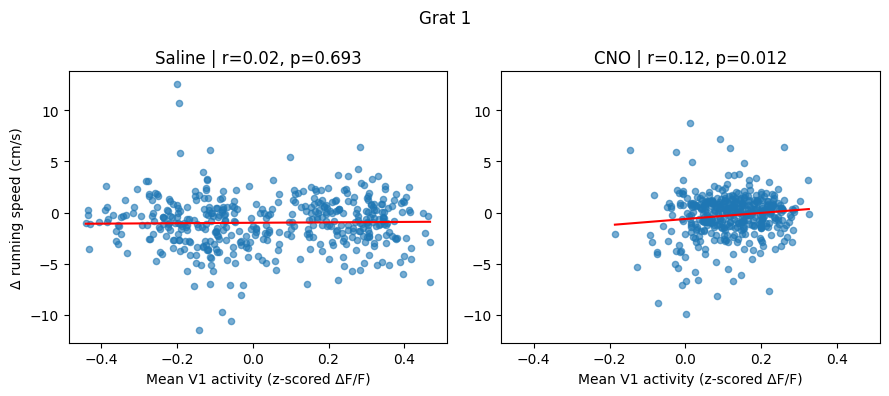

In [ ]:
# delta speed versus mean V1 response across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 1')
plt.tight_layout()
plt.show()

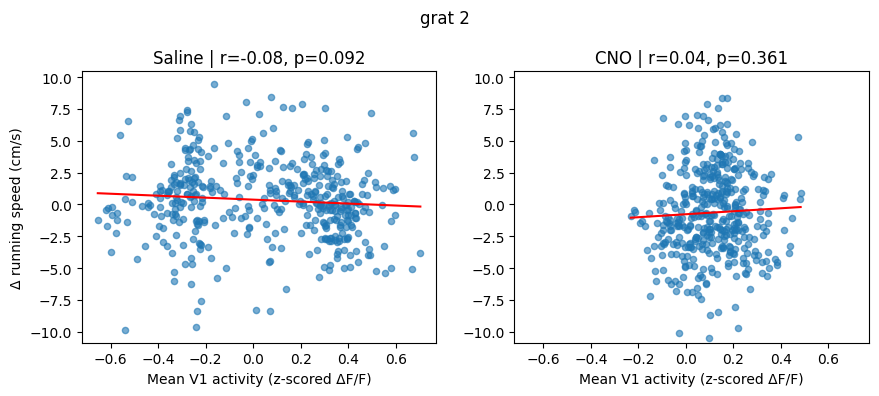

In [ ]:
# delta speed (avg 20 frames pre - avg 20 frames post) versus average mean V1 activity across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][:,:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][:,20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,:,:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][:,:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][:,20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,:,:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('grat 2')
plt.tight_layout()
plt.show()

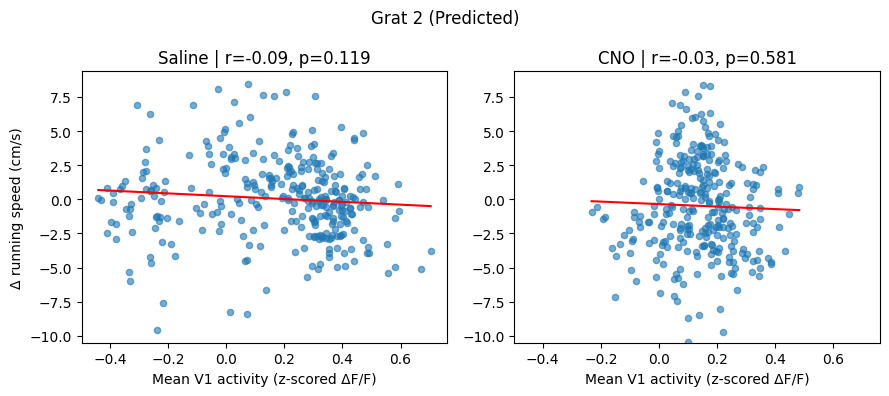

In [437]:
# delta speed (avg 20 frames pre - avg 20 frames post) versus average mean V1 activity across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,data[ani]['pred_trials'],:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,data[ani]['pred_trials'],:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 2 (Predicted)')
plt.tight_layout()
plt.show()

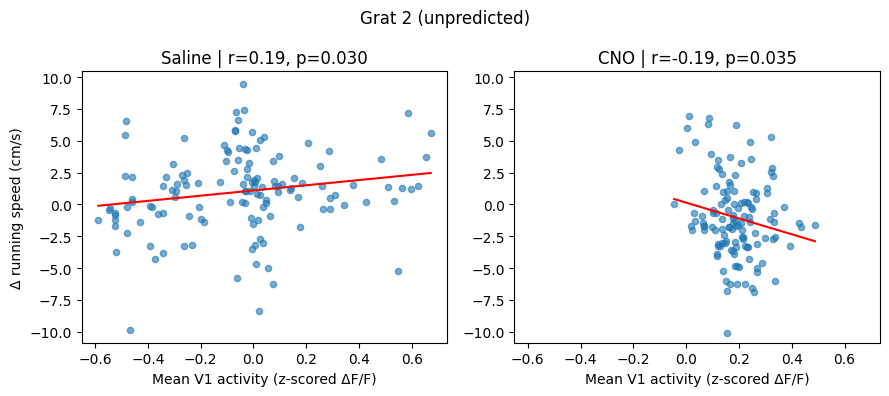

In [438]:
# delta speed (avg 20 frames pre - avg 20 frames post) versus average mean V1 activity across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:,:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:,20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'],:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:,:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:,20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'],:40],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 2 (unpredicted)')
plt.tight_layout()
plt.show()

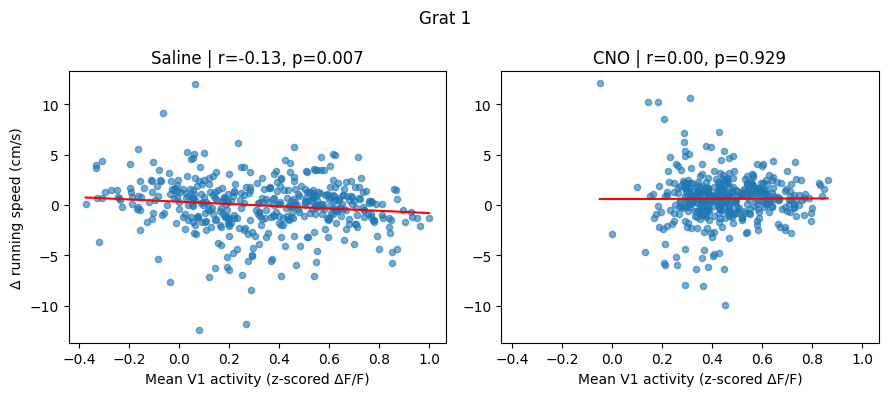

In [ ]:
# delta speed (avg 20 frames pre - avg 20 frames post) versus stim evoked response across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    speed = data[ani]['speed'].values
    delta_speed.append(np.mean(speed[data[ani]['grating_indices']['gr_1']][:,10:20],axis=1)-np.mean(speed[data[ani]['grating_indices']['gr_1']][:,20:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,poststim_frames],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)
ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,10:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,20:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,poststim_frames],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 1')
plt.tight_layout()
plt.show()

--------------------------------------------

In [633]:
np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,23:30],axis=2),axis=0).shape

(210,)

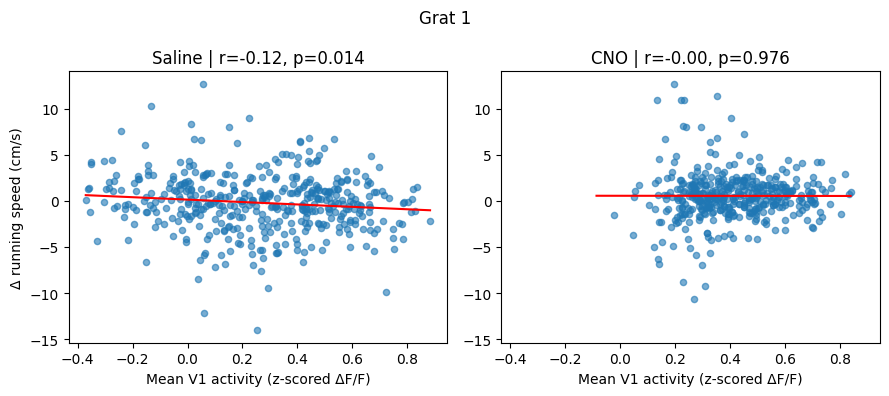

In [ ]:
# delta speed (avg 20 frames pre - avg 20 frames post) versus stim evoked response across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))

ax = axes[0]
delta_speed_sal = []
all_activity_sal = []
ctl = [1,3]
tst = [0,2]
for ani in ctl:
    delta_speed_sal.append(np.mean(data[ani]['speed_cm_s']['gr_1'][:,13:20],axis=1)-np.mean(data[ani]['speed_cm_s']['gr_1'][:,23:30],axis=1))
    all_activity_sal.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,23:30],axis=2),axis=0))
delta_speed_sal, all_activity_sal = np.concatenate(delta_speed_sal), np.concatenate(all_activity_sal)
ax.scatter(all_activity_sal, delta_speed_sal, alpha=0.6, s=20)
r, p = scipy.stats.pearsonr(all_activity_sal, delta_speed_sal)
m, b = np.polyfit(all_activity_sal, delta_speed_sal, 1)
x_line = np.linspace(all_activity_sal.min(), all_activity_sal.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)
ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed_cno = []
all_activity_cno = []
for ani in tst:
    delta_speed_cno.append(np.mean(data[ani]['speed_cm_s']['gr_1'][:,13:20],axis=1)-np.mean(data[ani]['speed_cm_s']['gr_1'][:,23:30],axis=1))
    all_activity_cno.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,23:30],axis=2),axis=0))
delta_speed_cno, all_activity_cno = np.concatenate(delta_speed_cno), np.concatenate(all_activity_cno)
ax.scatter(all_activity_cno, delta_speed_cno, alpha=0.6, s=20)
r, p = scipy.stats.pearsonr(all_activity_cno, delta_speed_cno)
m, b = np.polyfit(all_activity_cno, delta_speed_cno, 1)
x_line = np.linspace(all_activity_cno.min(), all_activity_cno.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)
ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 1')
plt.tight_layout()
plt.show()

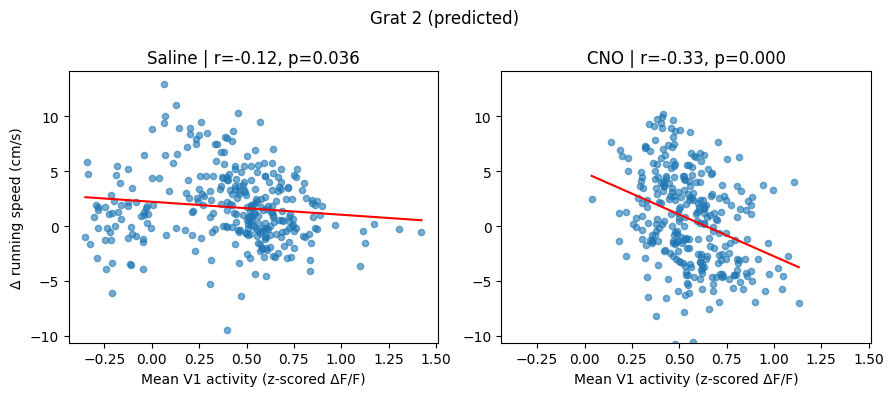

In [638]:
# delta speed (avg 20 frames pre - avg 20 frames post) versus stim evoked response across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['pred_trials']][:,13:20],axis=1)-np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['pred_trials']][:,23:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,data[ani]['pred_trials'],23:30],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)
ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
tst = [0,2]
for ani in tst:
    delta_speed.append(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['pred_trials']][:,13:20],axis=1)-np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['pred_trials']][:,23:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,data[ani]['pred_trials'],23:30],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 2 (predicted)')
plt.tight_layout()
plt.show()

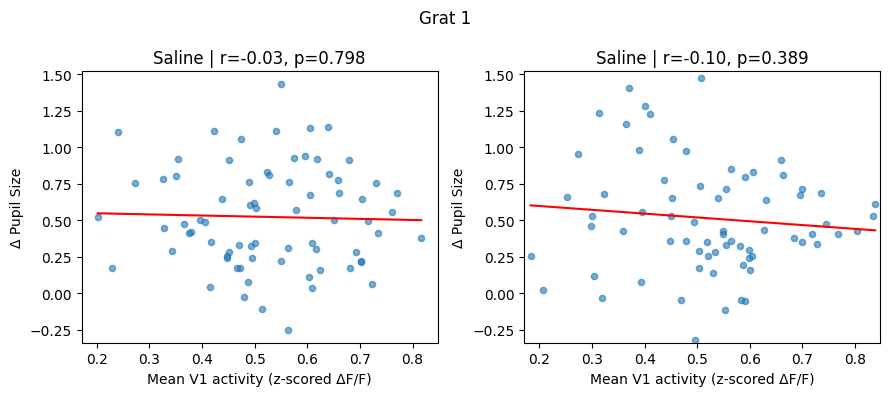

In [564]:
# delta pupil (avg 20 frames pre - avg 20 frames post) versus average mean V1 activity across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))

ax = axes[0]
delta_pupil = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    pupil = data[ani]['aligned_data']['pupil_long_axis'].values
    pupil = gaussian_filter1d(pupil, sigma=0.7)
    low, high = np.nanpercentile(pupil, 0.5), np.nanpercentile(pupil, 99.5)
    pupil[(pupil < low) | (pupil > high)] = np.nan
    delta_pupil.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_1']][:40,12:20],axis=1)-np.nanmean(pupil[data[ani]['grating_indices']['gr_1']][:40,23:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:40,23:30],axis=2),axis=0))
delta_pupil = np.concatenate(delta_pupil)
all_activity = np.concatenate(all_activity)

mask = ~np.isnan(delta_pupil) & ~np.isnan(all_activity)
all_activity = all_activity[mask]
delta_pupil = delta_pupil[mask]

ax.scatter(all_activity, delta_pupil, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_pupil)
m, b = np.polyfit(all_activity, delta_pupil, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ Pupil Size')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_pupil = []
all_activity = []
for ani in ctl:
    pupil = data[ani]['aligned_data']['pupil_long_axis'].values
    pupil = gaussian_filter1d(pupil, sigma=0.7)
    low, high = np.nanpercentile(pupil, 0.5), np.nanpercentile(pupil, 99.5)
    pupil[(pupil < low) | (pupil > high)] = np.nan
    delta_pupil.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_1']][40:80,12:20],axis=1)-np.nanmean(pupil[data[ani]['grating_indices']['gr_1']][40:80,23:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,40:80,23:30],axis=2),axis=0))
delta_pupil = np.concatenate(delta_pupil)
all_activity = np.concatenate(all_activity)

mask = ~np.isnan(delta_pupil) & ~np.isnan(all_activity)
all_activity = all_activity[mask]
delta_pupil = delta_pupil[mask]

ax.scatter(all_activity, delta_pupil, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_pupil)
m, b = np.polyfit(all_activity, delta_pupil, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ Pupil Size')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 1')

plt.tight_layout()
plt.show()

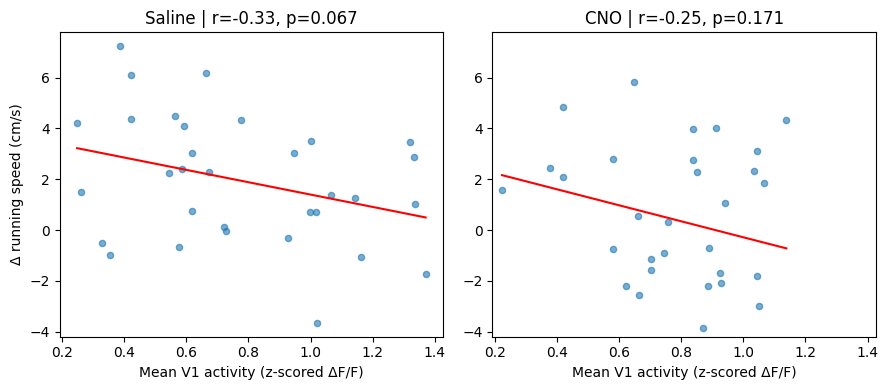

In [549]:
# delta speed (avg 20 frames post - avg 20 frames pre) versus average mean V1 activity across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
ctl = [1,3]
tst = [0,2]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:16,10:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:16,20:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
for ani in tst:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:16,10:20],axis=1)-np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:16,20:30],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
plt.tight_layout()
plt.show()

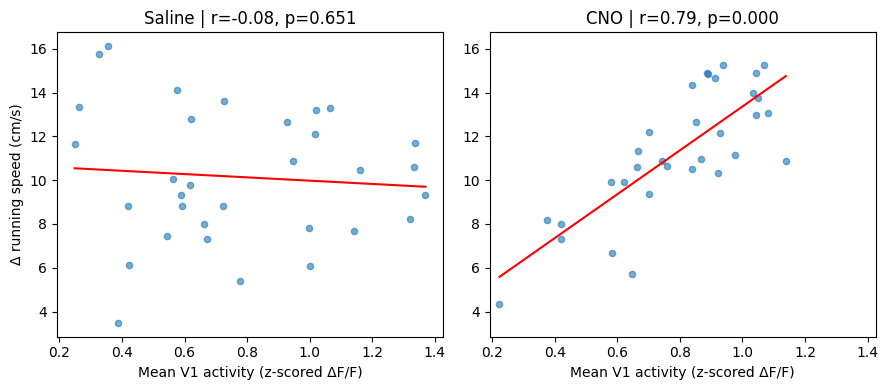

In [ ]:
fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_speed = []
all_activity = []
tst = [0,2]
ctl = [1,3]
for ani in ctl:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:16,poststim_frames],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_speed = []
all_activity = []
for ani in tst:
    delta_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['unpred_trials']['gr_2']][:16,poststim_frames],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=2),axis=0))
delta_speed = np.concatenate(delta_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, delta_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_speed)
m, b = np.polyfit(all_activity, delta_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
plt.tight_layout()
plt.show()

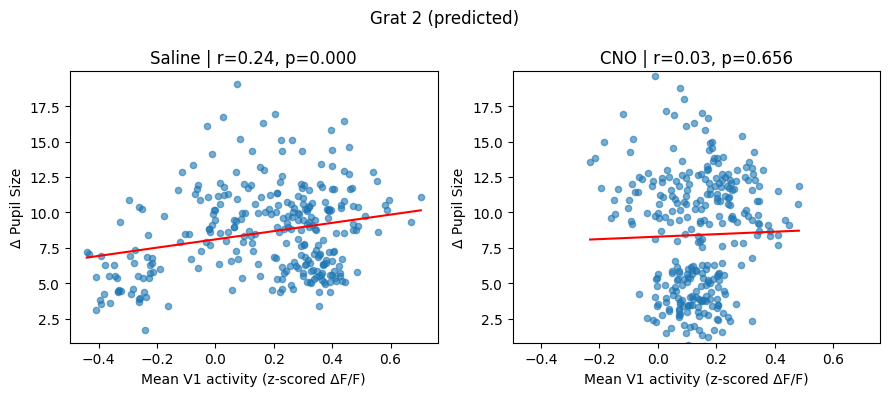

In [453]:
# delta pupil (avg 20 frames pre - avg 20 frames post) versus average mean V1 activity across all responsive neurons neuron

fig,axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]
delta_pupil = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    pupil = data[ani]['aligned_data']['pupil_long_axis'].values
    pupil = gaussian_filter1d(pupil, sigma=0.7)
    low, high = np.nanpercentile(pupil, 0.5), np.nanpercentile(pupil, 99.5)
    pupil[(pupil < low) | (pupil > high)] = np.nan
    delta_pupil.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],:20],axis=1)-np.nanmean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,data[ani]['pred_trials'],:40],axis=2),axis=0))
delta_pupil = np.concatenate(delta_pupil)
all_activity = np.concatenate(all_activity)

mask = ~np.isnan(delta_pupil) & ~np.isnan(all_activity)
all_activity = all_activity[mask]
delta_pupil = delta_pupil[mask]

ax.scatter(all_activity, delta_pupil, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_pupil)
m, b = np.polyfit(all_activity, delta_pupil, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ Pupil Size')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')

ax = axes[1]
delta_pupil = []
all_activity = []
ctl = [0,2]
for ani in ctl:
    pupil = data[ani]['aligned_data']['pupil_long_axis'].values
    low, high = np.nanpercentile(pupil, 0.5), np.nanpercentile(pupil, 99.5)
    pupil[(pupil < low) | (pupil > high)] = np.nan
    pupil = gaussian_filter1d(pupil, sigma=0.7)
    delta_pupil.append(np.nanmean(pupil[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],:20],axis=1)-np.nanmean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_2']][data[ani]['pred_trials'],20:40],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_2'][sig_cells[ani]['gr_2']][:,data[ani]['pred_trials'],:40],axis=2),axis=0))
delta_pupil = np.concatenate(delta_pupil)
all_activity = np.concatenate(all_activity)

mask = ~np.isnan(delta_pupil) & ~np.isnan(all_activity)
all_activity = all_activity[mask]
delta_pupil = delta_pupil[mask]

ax.scatter(all_activity, delta_pupil, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, delta_pupil)
m, b = np.polyfit(all_activity, delta_pupil, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Δ Pupil Size')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
fig.suptitle('Grat 2 (predicted)')
plt.tight_layout()
plt.show()

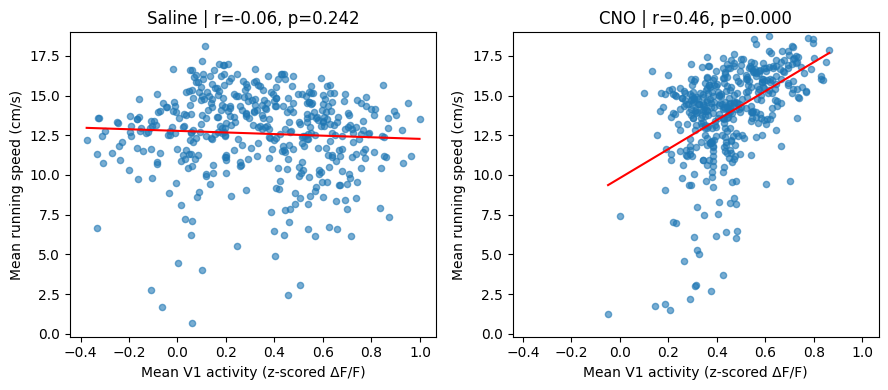

In [ ]:
# # mean speed/pupil versus average activity across all responsive neurons neurons mean activity & mean running speed in post stim frames

# fig,axes = plt.subplots(1,2, figsize = (9,4))
# ax = axes[0]
# all_speed = []
# all_activity = []
# ctl = [1,3]
# for ani in ctl:
#     all_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,poststim_frames],axis=1))
#     all_activity.append( np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,poststim_frames],axis=2),axis=0))
# all_speed = np.concatenate(all_speed)
# all_activity = np.concatenate(all_activity)

# ax.scatter(all_activity, all_speed, alpha=0.6, s=20)

# r, p = scipy.stats.pearsonr(all_activity, all_speed)
# m, b = np.polyfit(all_activity, all_speed, 1)
# x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
# ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

# ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
# ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')


# ax = axes[1]
# all_speed = []
# all_activity = []
# tst = [0,2]
# for ani in tst:
#     all_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']][:,poststim_frames],axis=1))
#     all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,:,poststim_frames],axis=2),axis=0))
# all_speed = np.concatenate(all_speed)
# all_activity = np.concatenate(all_activity)

# ax.scatter(all_activity, all_speed, alpha=0.6, s=20)

# r, p = scipy.stats.pearsonr(all_activity, all_speed)
# m, b = np.polyfit(all_activity, all_speed, 1)
# x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
# ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

# ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
# ax.set_ylabel('Mean running speed (cm/s)')
# ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
# axes[1].set_ylim(axes[0].get_ylim())
# axes[1].set_xlim(axes[0].get_xlim())
# plt.tight_layout()
# plt.show()

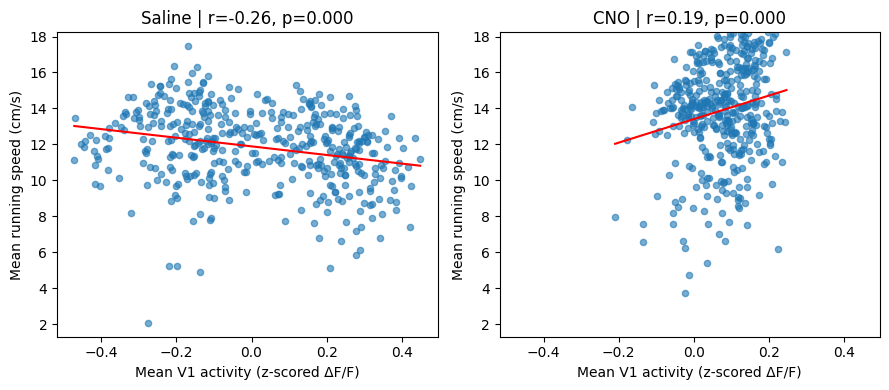

In [283]:
# mean speed/pupil versus average activity across all responsive neurons neurons mean activity & mean running speed in post stim frames

fig,axes = plt.subplots(1,2, figsize = (9,4))

ax = axes[0]
all_speed = []
all_activity = []
ctl = [1,3]
for ani in ctl:
    all_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']],axis=1))
    all_activity.append( np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']],axis=2),axis=0))
all_speed = np.concatenate(all_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, all_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, all_speed)
m, b = np.polyfit(all_activity, all_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'Saline | r={r:.2f}, p={p:.3f}')


ax = axes[1]
all_speed = []
all_activity = []
tst = [0,2]
for ani in tst:
    all_speed.append(np.mean(data[ani]['speed'].values[data[ani]['grating_indices']['gr_1']],axis=1))
    all_activity.append(np.mean(np.mean(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']],axis=2),axis=0))

all_speed = np.concatenate(all_speed)
all_activity = np.concatenate(all_activity)

ax.scatter(all_activity, all_speed, alpha=0.6, s=20)

r, p = scipy.stats.pearsonr(all_activity, all_speed)
m, b = np.polyfit(all_activity, all_speed, 1)
x_line = np.linspace(all_activity.min(), all_activity.max(), 100)
ax.plot(x_line, m * x_line + b, 'r', linewidth=1.5)

ax.set_xlabel('Mean V1 activity (z-scored ΔF/F)')
ax.set_ylabel('Mean running speed (cm/s)')
ax.set_title(f'CNO | r={r:.2f}, p={p:.3f}')
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(axes[0].get_xlim())
plt.tight_layout()
plt.show()

Fast and slow running trials. For the analysis in Extended Data Fig.1k,l, trials in block 1 and 2 were divided into fast and slow running trials based on mean running speed during presentation of grating C4. A time window starting 0.4 s and ending 2 s after the grating onset, similar to the response window used for calcium responses, was used to calculate the mean running speed. A trial was defined as ‘fast’ or ‘slow’ if the mean running speed during the time window was in the top 50th or bottom 50th percentile of all visual stimulus C4 presentations in block 1 or 2.

Text(0.5, 0.98, 'Block1')

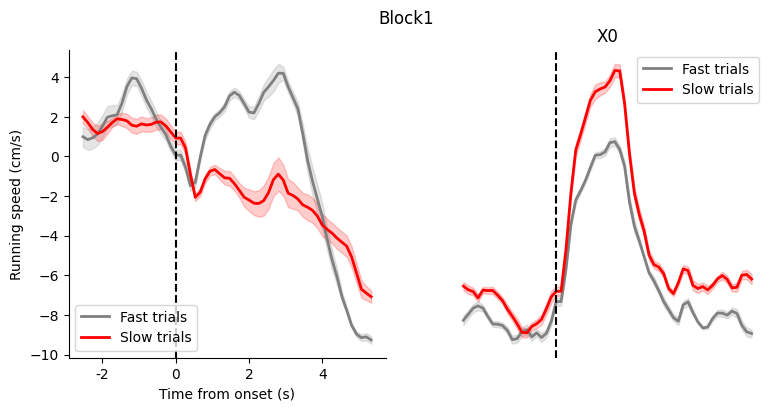

In [176]:
# Reproduce Shohei's plots --- slow trials & fast trials Block1 Saline

fig, axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]

slow_trials_speed = []
fast_trials_speed = []
slow_trials_activity = []
fast_trials_activity = []

ctl = [1,3]

for ani in ctl:
    sorted_idx = np.argsort(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=1))
    slow_tri = []
    fast_tri = []
    for idx in sorted_idx[:len(sorted_idx)//2]:   # first half of the idx
        slow_tri.append(data[ani]['unpred_trials']['gr_2'][:16][idx])
    for idx in sorted_idx[len(sorted_idx)//2:]:   # other half of the idx
        fast_tri.append(data[ani]['unpred_trials']['gr_2'][:16][idx])
    slow_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][slow_tri,:])
    fast_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][fast_tri,:])
    slow_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,slow_tri]) 
    fast_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,fast_tri]) 
    # activity of the X0 responsive cells in slow and fast trials

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(fast_trials_speed),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(slow_trials_speed),color='red',label='Slow trials',)

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim([-2,5])
# ax.set_yticks()
ax.set_ylabel('Running speed (cm/s)')
ax.set_xticks([4, 19, 34, 49])
ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_xlabel('Time from onset (s)')
# ax.set_title('Block 1')


ax = axes[1]
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(fast_trials_activity),axis=0),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(slow_trials_activity),axis=0),color='red',label='Slow trials')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('X0')
fig.suptitle('Block1')

Text(0.5, 0.98, 'Block2')

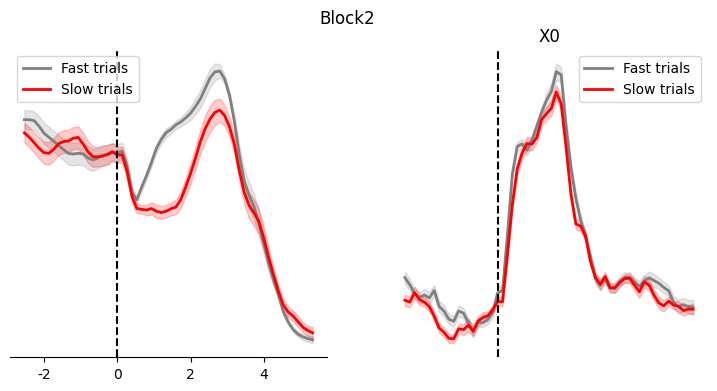

In [49]:
# Reproduce Shohei's plots --- slow trials & fast trials Block2 Saline

fig, axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]

slow_trials_speed = []
fast_trials_speed = []
slow_trials_activity = []
fast_trials_activity = []

ctl = [1,3]

for ani in ctl:
    sorted_idx = np.argsort(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['unpred_trials']['gr_2'][16:60],poststim_frames],axis=1))
    slow_tri = []
    fast_tri = []
    for idx in sorted_idx[:len(sorted_idx)//2]:   # first half of the idx
        slow_tri.append(data[ani]['unpred_trials']['gr_2'][16:60][idx])
    for idx in sorted_idx[len(sorted_idx)//2:]:   # other half of the idx
        fast_tri.append(data[ani]['unpred_trials']['gr_2'][16:60][idx])
    slow_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][slow_tri,:])
    fast_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][fast_tri,:])
    slow_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,slow_tri]) 
    fast_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,fast_tri]) 
    # activity of the X0 responsive cells in slow and fast trials

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(fast_trials_speed),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(slow_trials_speed),color='red',label='Slow trials',)

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# ax.set_ylim([-2,5])
ax.set_yticks([])
# ax.set_ylabel('relative pupil size')
ax.set_xticks([4, 19, 34, 49])
ax.set_xticklabels(['-2', '0', '2', '4'])
# ax.set_title('Block 2')


ax = axes[1]
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(fast_trials_activity),axis=0),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(slow_trials_activity),axis=0),color='red',label='Slow trials')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('X0')
fig.suptitle('Block2')

Text(0.5, 0.98, 'CNO')

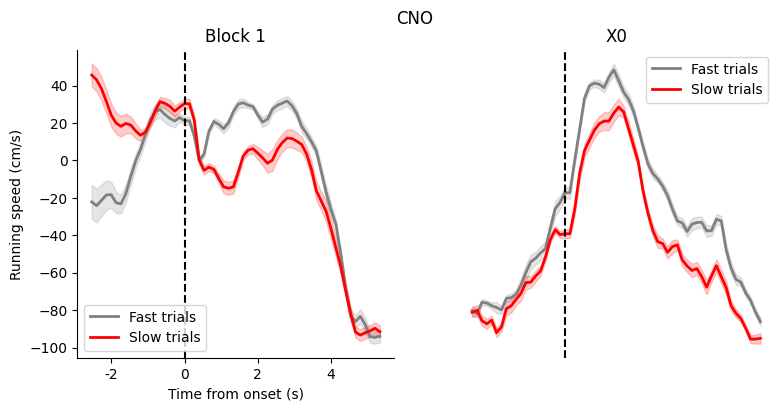

In [24]:
# Reproduce Shohei's plots --- slow trials & fast trials Block1 CNO

fig, axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]

slow_trials_speed = []
fast_trials_speed = []
slow_trials_activity = []
fast_trials_activity = []

for ani in tst:
    sorted_idx = np.argsort(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=1))
    slow_tri = []
    fast_tri = []
    for idx in sorted_idx[:len(sorted_idx)//2]:   # first half of the idx
        slow_tri.append(data[ani]['unpred_trials']['gr_2'][:16][idx])
    for idx in sorted_idx[len(sorted_idx)//2:]:   # other half of the idx
        fast_tri.append(data[ani]['unpred_trials']['gr_2'][:16][idx])
    slow_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][slow_tri,:])
    fast_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][fast_tri,:])
    slow_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,slow_tri]) 
    fast_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,fast_tri]) 
    # activity of the X0 responsive cells in slow and fast trials

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(fast_trials_speed),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(slow_trials_speed),color='red',label='Slow trials',)

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim([-2,5])
# ax.set_yticks()
ax.set_ylabel('Running speed (cm/s)')
ax.set_xticks([4, 19, 34, 49])
ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_xlabel('Time from onset (s)')
ax.set_title('Block 1')


ax = axes[1]
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(fast_trials_activity),axis=0),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(slow_trials_activity),axis=0),color='red',label='Slow trials')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('X0')
fig.suptitle('CNO')

-0.18142793908080151
-0.20033817576887578


Text(0.5, 0.98, 'CNO')

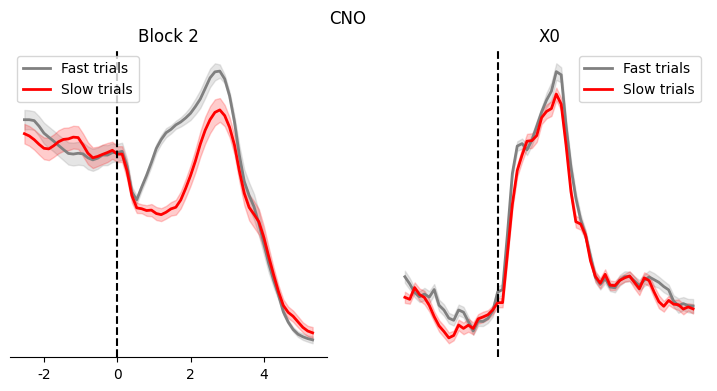

In [636]:
# Reproduce Shohei's plots --- slow trials & fast trials Block2 CNO

fig, axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]

slow_trials_speed = []
fast_trials_speed = []
slow_trials_activity = []
fast_trials_activity = []
ctl = [1,3]

for ani in ctl:
    sorted_idx = np.argsort(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['unpred_trials']['gr_2'][16:59],poststim_frames],axis=1))
    slow_tri = []
    fast_tri = []
    for idx in sorted_idx[:len(sorted_idx)//2]:   # first half of the idx
        slow_tri.append(data[ani]['unpred_trials']['gr_2'][16:59][idx])
    for idx in sorted_idx[len(sorted_idx)//2:]:   # other half of the idx
        fast_tri.append(data[ani]['unpred_trials']['gr_2'][16:59][idx])
    slow_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][slow_tri,:])
    fast_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][fast_tri,:])
    slow_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,slow_tri]) 
    fast_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,fast_tri]) 
    # activity of the X0 responsive cells in slow and fast trials


viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(fast_trials_speed),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(slow_trials_speed),color='red',label='Slow trials',)

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# ax.set_ylim([-2,5])
ax.set_yticks([])
# ax.set_ylabel('relative pupil size')
ax.set_xticks([4, 19, 34, 49])
ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('Block 2')



print(np.mean(np.vstack(fast_trials_activity)))
print(np.mean(np.vstack(slow_trials_activity)))


ax = axes[1]
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(fast_trials_activity),axis=0),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(slow_trials_activity),axis=0),color='red',label='Slow trials')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('X0')
fig.suptitle('CNO')

(333, 8, 60)
(333, 8, 60)


Text(0.5, 0.98, 'Block1')

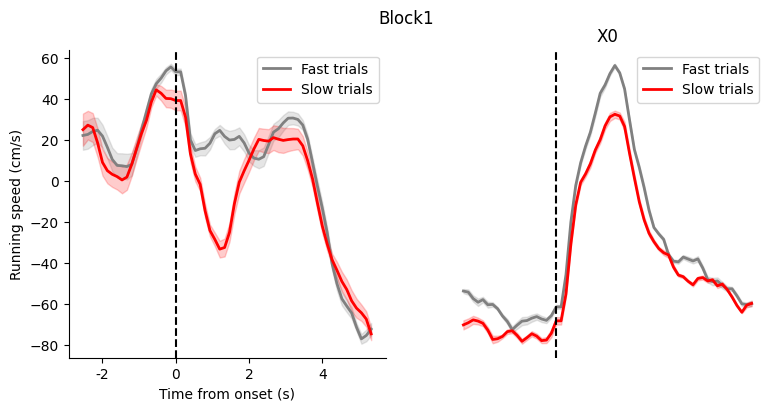

In [26]:
# Reproduce Shohei's plots --- slow trials & fast trials Block1 Saline

fig, axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]

slow_trials_speed = []
fast_trials_speed = []
slow_trials_activity = []
fast_trials_activity = []

ctl = [5,7]

for ani in ctl:
    sorted_idx = np.argsort(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['unpred_trials']['gr_2'][:16],poststim_frames],axis=1))
    slow_tri = []
    fast_tri = []
    for idx in sorted_idx[:len(sorted_idx)//2]:   # first half of the idx
        slow_tri.append(data[ani]['unpred_trials']['gr_2'][:16][idx])
    for idx in sorted_idx[len(sorted_idx)//2:]:   # other half of the idx
        fast_tri.append(data[ani]['unpred_trials']['gr_2'][:16][idx])
    slow_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][slow_tri,:])
    fast_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][fast_tri,:])
    slow_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,slow_tri]) 
    fast_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,fast_tri]) 
    # activity of the X0 responsive cells in slow and fast trials

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(fast_trials_speed),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(slow_trials_speed),color='red',label='Slow trials',)

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim([-2,5])
# ax.set_yticks()
ax.set_ylabel('Running speed (cm/s)')
ax.set_xticks([4, 19, 34, 49])
ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_xlabel('Time from onset (s)')
# ax.set_title('Block 1')


print(np.vstack(fast_trials_activity).shape)
print(np.vstack(slow_trials_activity).shape)

ax = axes[1]
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(fast_trials_activity),axis=0),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(slow_trials_activity),axis=0),color='red',label='Slow trials')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('X0')
fig.suptitle('Block1')

(333, 20, 60)


Text(0.5, 0.98, 'Block2')

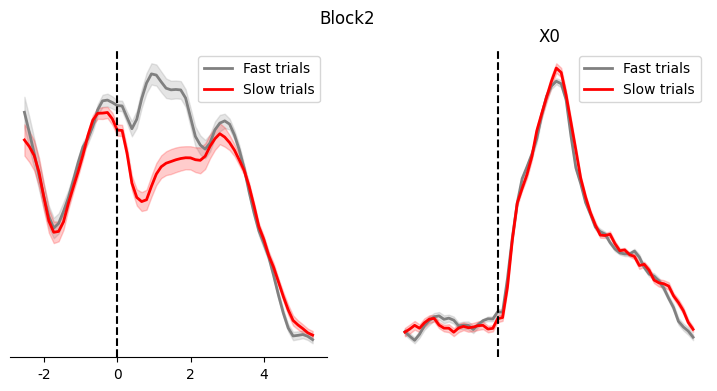

In [ ]:
# Reproduce Shohei's plots --- slow trials & fast trials Block2 Saline

fig, axes = plt.subplots(1,2, figsize = (9,4))
ax = axes[0]

slow_trials_speed = []
fast_trials_speed = []
slow_trials_activity = []
fast_trials_activity = []

ctl = [5,7]

for ani in ctl:
    sorted_idx = np.argsort(np.mean(data[ani]['speed_cm_s']['gr_2'][data[ani]['unpred_trials']['gr_2'][16:55],poststim_frames],axis=1))
    slow_tri = []
    fast_tri = []
    for idx in sorted_idx[:len(sorted_idx)//2]:   # first half of the idx
        slow_tri.append(data[ani]['unpred_trials']['gr_2'][16:55][idx])
    for idx in sorted_idx[len(sorted_idx)//2:]:   # other half of the idx
        fast_tri.append(data[ani]['unpred_trials']['gr_2'][16:55][idx])
    slow_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][slow_tri,:])
    fast_trials_speed.append(data[ani]['speed_cm_s']['gr_2'][fast_tri,:])
    slow_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,slow_tri]) 
    fast_trials_activity.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,fast_tri]) 
    # activity of the X0 responsive cells in slow and fast trials

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(fast_trials_speed),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(slow_trials_speed),color='red',label='Slow trials',)

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
# ax.set_ylabel('relative pupil size')
ax.set_xticks([4, 19, 34, 49])
ax.set_xticklabels(['-2', '0', '2', '4'])
# ax.set_title('Block 2')


print(np.vstack(fast_trials_activity).shape)

ax = axes[1]
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(fast_trials_activity),axis=0),color='grey',label='Fast trials')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.mean(np.vstack(slow_trials_activity),axis=0),color='red',label='Slow trials')

ax.axvline(19, linestyle='--', color='k')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.set_ylim([-2,5])
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticklabels(['-2', '0', '2', '4'])
ax.set_title('X0')
fig.suptitle('Block2')

Correlation of running speed and neuronal activity. To determine the effect of running speed on neuronal activity (Extended Data Fig.1m,n), we computed for each cell the correlation between mean ΔF/F and mean running speed in a time window (starting 0.4 s and ending 2 s after grating stimulus onset) of each trial in block 1 or 2. For the analysis in Extended Data Fig.1o, we used the square of the correlation coefficient (R2, coefficient of determination) of running speed and ΔF/F across the recording, to quantify the strength of the modulation of neural responses by running speed across the entire session (block 1 and 2).

Jordan & Keller 2023

Correlate V1 activity with Pupil

Cross-correlations between LC axonal ΔF/F and pupil diameter (black) or the time derivative of pupil diameter (gray) averaged across 40 FoVs. Shading indicates SEM. Positive axonal lag values indicate time delays where axonal fluorescence lags relative to pupil diameter or its derivative. 

All ΔF/F

Pupil --- remove outliers top/bottom 5%, (remove blinking could be done)

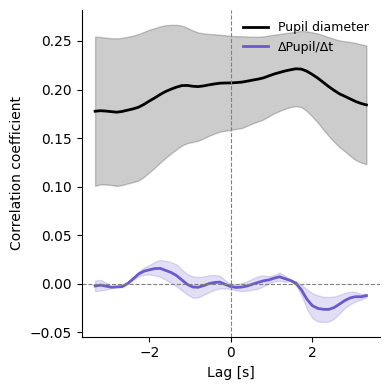

In [28]:
Corr_all = []
Corr2_all = []
for ani in [1,3]:
    activity = np.nanmean(data[ani]['dff_Zscore'],axis=0)
    pup_d = data[ani]['pupil'].astype(float)
    pup_d = (gaussian_filter1d(pup_d, sigma=1))
    pup_d2 = np.diff(pup_d)

    # Remove outliers from both signals
    pup_d = pup_d[1:]
    activity = activity[1:]
    low, high = np.nanpercentile(pup_d, 0.5), np.nanpercentile(pup_d, 99.5)
    pup_d[(pup_d < low) | (pup_d > high)] = np.nan
    low2, high2 = np.nanpercentile(pup_d2, 0.5), np.nanpercentile(pup_d2, 99.5)
    pup_d2[(pup_d2 < low2) | (pup_d2 > high2)] = np.nan

    n_lags = 25
    Corr  = np.full(2 * n_lags + 1, np.nan)
    Corr2 = np.full(2 * n_lags + 1, np.nan)

    for arr, C in [(pup_d, Corr), (pup_d2, Corr2)]:
        mask = np.isfinite(activity) & np.isfinite(arr)
        C[n_lags] = np.corrcoef(activity[mask], arr[mask])[0, 1]

        for offset in range(1, n_lags + 1):
            # ACT leads pupil (positive lag)
            mask = np.isfinite(activity[:-offset]) & np.isfinite(arr[offset:])
            C[n_lags + offset] = np.corrcoef(activity[:-offset][mask], arr[offset:][mask])[0, 1]
            # Pupil leads ACT (negative lag)
            mask = np.isfinite(activity[offset:]) & np.isfinite(arr[:-offset])
            C[n_lags - offset] = np.corrcoef(activity[offset:][mask], arr[:-offset][mask])[0, 1]

    Corr_all.append(Corr)
    Corr2_all.append(Corr2)

Corr_all  = np.array(Corr_all)
Corr2_all = np.array(Corr2_all)
lags = np.arange(-n_lags, n_lags + 1) /7.5

mean1, se1 = np.nanmean(Corr_all, axis=0),  np.nanstd(Corr_all, axis=0)  / np.sqrt(len(Corr_all))
mean2, se2 = np.nanmean(Corr2_all, axis=0), np.nanstd(Corr2_all, axis=0) / np.sqrt(len(Corr2_all))

fig, ax = plt.subplots(figsize=(4, 4))
ax.fill_between(lags, mean1 - se1, mean1 + se1, color='black', alpha=0.2)
ax.plot(lags, mean1, color='black', lw=2, label='Pupil diameter')
ax.fill_between(lags, mean2 - se2, mean2 + se2, color='slateblue', alpha=0.2)
ax.plot(lags, mean2, color='slateblue', lw=2, label='ΔPupil/Δt')

ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.axvline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel('Lag [s]')
ax.set_ylabel('Correlation coefficient')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

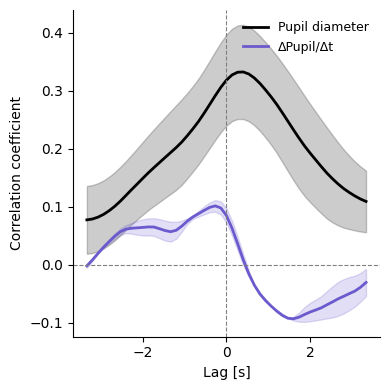

In [29]:
Corr_all = []
Corr2_all = []
for ani in [5,7]:
    activity = np.nanmean(data[ani]['dff_Zscore'],axis=0)
    pup_d = data[ani]['pupil'].astype(float)
    pup_d = (gaussian_filter1d(pup_d, sigma=1))
    pup_d2 = np.diff(pup_d)

    # Remove outliers from both signals
    pup_d = pup_d[1:]
    activity = activity[1:]
    low, high = np.nanpercentile(pup_d, 0.5), np.nanpercentile(pup_d, 99.5)
    pup_d[(pup_d < low) | (pup_d > high)] = np.nan
    low2, high2 = np.nanpercentile(pup_d2, 0.5), np.nanpercentile(pup_d2, 99.5)
    pup_d2[(pup_d2 < low2) | (pup_d2 > high2)] = np.nan

    n_lags = 25
    Corr  = np.full(2 * n_lags + 1, np.nan)
    Corr2 = np.full(2 * n_lags + 1, np.nan)

    for arr, C in [(pup_d, Corr), (pup_d2, Corr2)]:
        mask = np.isfinite(activity) & np.isfinite(arr)
        C[n_lags] = np.corrcoef(activity[mask], arr[mask])[0, 1]

        for offset in range(1, n_lags + 1):
            # ACT leads pupil (positive lag)
            mask = np.isfinite(activity[:-offset]) & np.isfinite(arr[offset:])
            C[n_lags + offset] = np.corrcoef(activity[:-offset][mask], arr[offset:][mask])[0, 1]
            # Pupil leads ACT (negative lag)
            mask = np.isfinite(activity[offset:]) & np.isfinite(arr[:-offset])
            C[n_lags - offset] = np.corrcoef(activity[offset:][mask], arr[:-offset][mask])[0, 1]

    Corr_all.append(Corr)
    Corr2_all.append(Corr2)

Corr_all  = np.array(Corr_all)
Corr2_all = np.array(Corr2_all)
lags = np.arange(-n_lags, n_lags + 1) /7.5

mean1, se1 = np.nanmean(Corr_all, axis=0),  np.nanstd(Corr_all, axis=0)  / np.sqrt(len(Corr_all))
mean2, se2 = np.nanmean(Corr2_all, axis=0), np.nanstd(Corr2_all, axis=0) / np.sqrt(len(Corr2_all))

fig, ax = plt.subplots(figsize=(4, 4))
ax.fill_between(lags, mean1 - se1, mean1 + se1, color='black', alpha=0.2)
ax.plot(lags, mean1, color='black', lw=2, label='Pupil diameter')
ax.fill_between(lags, mean2 - se2, mean2 + se2, color='slateblue', alpha=0.2)
ax.plot(lags, mean2, color='slateblue', lw=2, label='ΔPupil/Δt')

ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.axvline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel('Lag [s]')
ax.set_ylabel('Correlation coefficient')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()